# House Price Prediction Project
## Objective: To build a machine learning model that accurately predicts house prices in Bangalore and Hyderabad.

## Workflow:

    Data Loading & Inspection
    Data Cleaning (Handling missing values, Ghost values)
    Feature Engineering (Luxury Score, Location Value)
    Outlier Removal
    Model Building (Linear Regression vs Gradient Boosting)
    Model Deployment Preparation


## Import Libraries & Load Data

In [56]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
import pickle
import json

In [57]:
df = pd.read_csv(r'C:\House_prediction\houses.csv')
df.head()

,Price,Area,Location,City,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,30000000,3340,JP Nagar Phase 1,Bangalore,4,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,Bangalore,2,0,0,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,Bangalore,2,0,0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,Bangalore,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,Bangalore,3,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0


In [58]:
# Check the size (Rows, Columns)
print("Shape of the dataset:", df.shape)

# Get a summary of the data (check for missing values and data types)
df.info()

Shape of the dataset: (32963, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32963 entries, 0 to 32962
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                32963 non-null  int64 
 1   Area                 32963 non-null  int64 
 2   Location             32963 non-null  object
 3   City                 32963 non-null  object
 4   No. of Bedrooms      32963 non-null  int64 
 5   Resale               32963 non-null  int64 
 6   MaintenanceStaff     32963 non-null  int64 
 7   Gymnasium            32963 non-null  int64 
 8   SwimmingPool         32963 non-null  int64 
 9   LandscapedGardens    32963 non-null  int64 
 10  JoggingTrack         32963 non-null  int64 
 11  RainWaterHarvesting  32963 non-null  int64 
 12  IndoorGames          32963 non-null  int64 
 13  ShoppingMall         32963 non-null  int64 
 14  Intercom             32963 non-null  int64 
 15  SportsFacility     

In [59]:
print(df.columns)

Index(['Price', 'Area', 'Location', 'City', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator'],
      dtype='object')


## Exploratory Data Analysis (EDA) - Heatmap

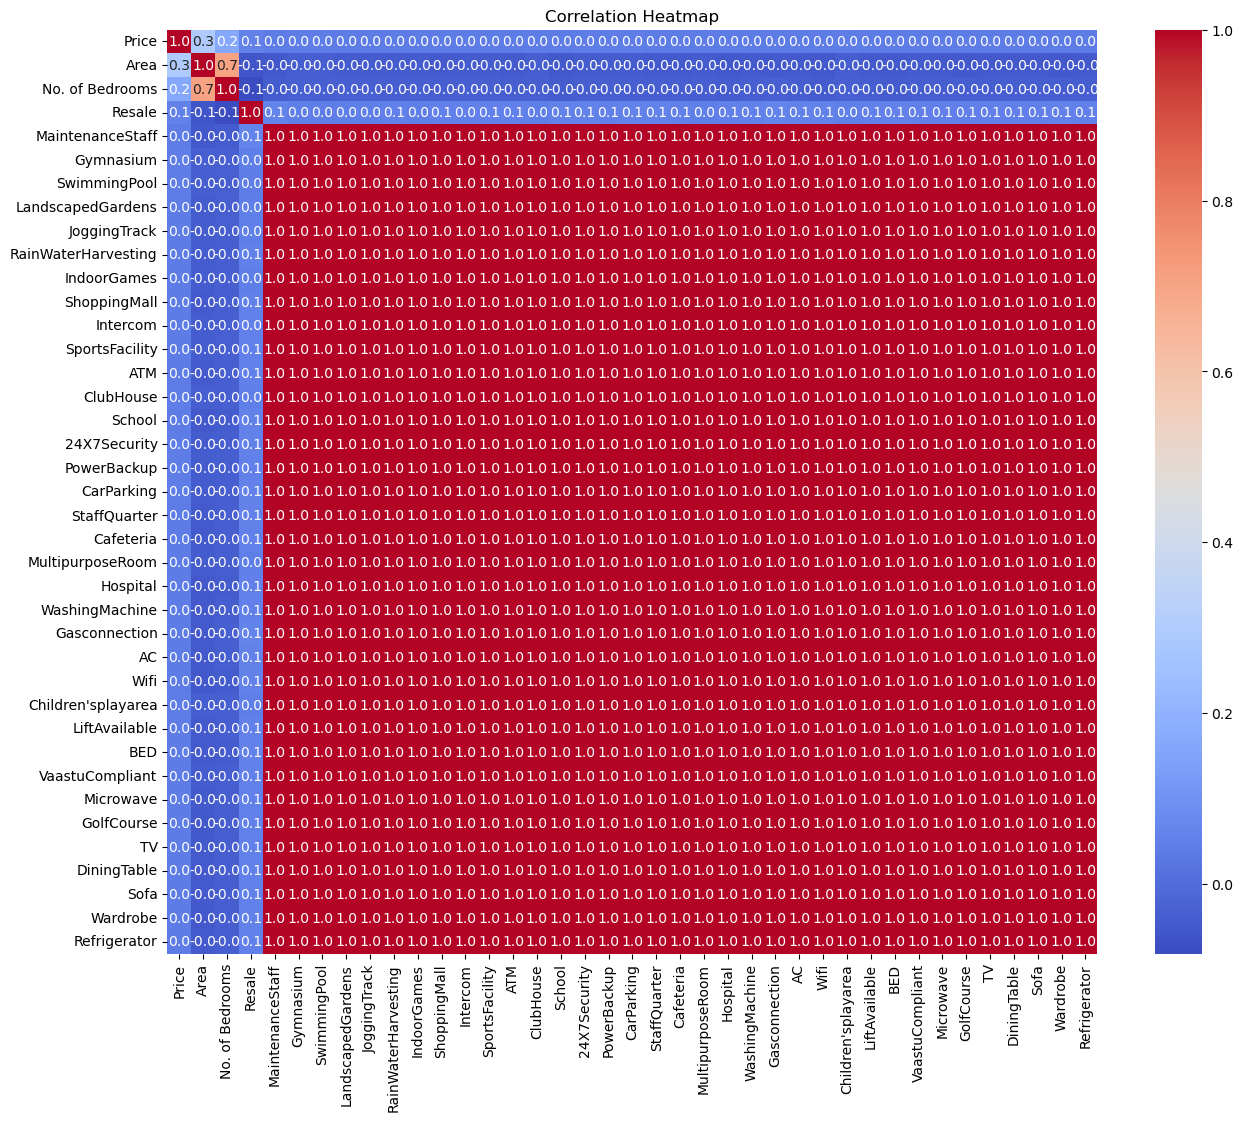

In [60]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15,12)) # Make the figure slightly larger so text fits
sns.heatmap(numeric_df.corr(), annot=True, fmt=".1f", cmap='coolwarm') # annot=True adds numbers
plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning
Issue: Amenity columns contain '9', which represents missing/unknown data.

Solution: Replace '9' with '0' to treat missing amenities as 'absent'.

In [61]:
amenity_cols = ['MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 
                'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 
                'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 
                'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 
                'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', 
                "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 
                'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator']

# Replace 9 with 0
for col in amenity_cols:
    df[col] = df[col].replace(9, 0)
    
print("Cleaned '9' values from amenities.")

Cleaned '9' values from amenities.


## City Selection
We filter for Bangalore and Hyderabad as these cities showed the best data quality and predictability during analysis.

In [62]:
# Filter for the two best-performing cities
df_model = df[df['City'].isin(['Bangalore', 'Hyderabad'])].copy()
print(f"Data size after city filter: {df_model.shape}")

Data size after city filter: (8725, 41)


## Feature Engineering
 Luxury Score: Aggregate all amenities into a single score.

Location Cleaning: Remove rare locations (less than 10 entries).

In [63]:
# 1. Create Luxury Score
df_model['Luxury_Score'] = df_model[amenity_cols].sum(axis=1)

# 2. Drop the individual amenity columns to reduce noise
df_model = df_model.drop(columns=amenity_cols)

# 3. Remove rare locations
location_stats = df_model['Location'].value_counts()
locations_to_keep = location_stats[location_stats > 10].index
df_model = df_model[df_model['Location'].isin(locations_to_keep)]

print(f"Data size after location filter: {df_model.shape}")

Data size after location filter: (7743, 7)


## Outlier Removal
Remove houses where the price per square foot is extreme (outside 1 Standard Deviation) for that specific location.

In [64]:
# 1. Calculate Price per Sqft
df_model['price_per_sqft'] = df_model['Price'] / df_model['Area']

# 2. Define Outlier Removal Function
def remove_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('Location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        # Keep only data within 1 Standard Deviation
        reduced_df = subdf[(subdf['price_per_sqft'] > (m-st)) & (subdf['price_per_sqft'] <= (m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

# 3. Apply function
df_clean = remove_outliers(df_model)

# 4. Drop the helper column
df_clean = df_clean.drop(['price_per_sqft'], axis=1)

print(f"Data size after outlier removal: {df_clean.shape}")

Data size after outlier removal: (6523, 7)


In [70]:
# 1. Group locations by city
# Note: Make sure you run this BEFORE you drop the 'City' column in the main code
# Or just ensure 'df_clean' exists in your memory.
locations_by_city = df_clean.groupby('City')['Location'].unique().to_dict()

# 2. Convert NumPy arrays to Python Lists (THE FIX)
for city in locations_by_city:
    locations_by_city[city] = locations_by_city[city].tolist()

# 3. Save to JSON
with open('locations_by_city.json', 'w') as f:
    json.dump(locations_by_city, f)

print("Created 'locations_by_city.json'. Move this to your VS Code folder.")

Created 'locations_by_city.json'. Move this to your VS Code folder.


##  Encoding
Target Encoding (Location): Convert Location name to its average price value.

One-Hot Encoding (City): Convert City column to numerical format.

In [65]:
# 1. Target Encoding for Location
loc_stats = df_clean.groupby('Location')['Price'].mean()
df_clean['Loc_Value'] = df_clean['Location'].map(loc_stats)

# Drop the text Location column
df_final = df_clean.drop(['Location'], axis=1)

# 2. One-Hot Encoding for City
# Creates 'City_Hyderabad' column (Bangalore will be 0, Hyderabad will be 1)
df_final = pd.get_dummies(df_final, columns=['City'], drop_first=True)

print("Encoding Complete.")
df_final.head()

Encoding Complete.


,Price,Area,No. of Bedrooms,Resale,Luxury_Score,Loc_Value,City_Hyderabad
0,6700000,1180,2,0,0,8213499.9,False
1,5800000,1185,2,0,0,8213499.9,False
2,8500000,1430,3,0,0,8213499.9,False
3,8400000,1180,2,0,0,8213499.9,False
4,4876000,1185,2,0,0,8213499.9,False


## Model Building & Evaluation
Comparing Linear Regression with Gradient Boosting.

In [66]:
# Define X and y
X = df_final.drop('Price', axis=1)
y = df_final['Price']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_score = lr.score(X_test, y_test)
print(f"Linear Regression R2 Score: {lr_score:.4f}")

# Model 2: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
gb_score = gb.score(X_test, y_test)
print(f"Gradient Boosting R2 Score: {gb_score:.4f}")

Linear Regression R2 Score: 0.7936
Gradient Boosting R2 Score: 0.8464


##  Saving Model Artifacts
Saving the best performing model (Gradient Boosting) and required JSON files for the Flask application.

In [67]:
# Save the Gradient Boosting Model (The 84% one)
with open('house_price_model.pickle', 'wb') as f:
    pickle.dump(gb, f)

# Save the Column Structure
with open('model_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

# Save the Location Stats Dictionary
with open('location_stats.json', 'w') as f:
    json.dump(loc_stats.to_dict(), f)

print("Files saved successfully!")
print(f"Final Accuracy to be reported: {gb_score:.2%}")

Files saved successfully!
Final Accuracy to be reported: 84.64%


In [68]:
print(X.columns.tolist())

['Area', 'No. of Bedrooms', 'Resale', 'Luxury_Score', 'Loc_Value', 'City_Hyderabad']
